# RetailPulse — AI-Powered Demand & Inventory Intelligence Platform
### EDA → RFM Segmentation → Demand Forecast → Churn Prediction → Inventory Optimization → Dashboard



## 0. Setup — install libraries

In [1]:
%pip install -q prophet xgboost shap pandas numpy scikit-learn matplotlib seaborn openpyxl statsmodels streamlit pyngrok


Note: you may need to restart the kernel to use updated packages.


## 1. Load the dataset (Day 1)

The UCI **Online Retail** dataset is an Excel file. We load it directly
from the UCI URL — no manual upload needed. If the UCI server is slow/down,
fall back to uploading the file manually (`files.upload()` cell is commented
below).

In [2]:
import pandas as pd
import numpy as np

DATA_URL = r"C:\Users\ASUS\OneDrive\Desktop\AI-Powered-Demand-Inventory-Intelligence\Online_Retail_UTF8.csv.xlsx"

try:
    df = pd.read_excel(DATA_URL)
    print("Loaded from UCI URL:", df.shape)
except Exception as e:
    print("Direct URL load failed:", e)
    print("Falling back to manual upload. Run the next cell.")


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loaded from UCI URL: (541909, 8)


In [3]:
if 'df' in locals():
    df.head()
else:
    print("Error: df not loaded. Check cell 4 for errors, or run the fallback upload in cell 5.")

## 2. Initial EDA 
Distribution analysis, missing values, correlation heatmap — before any cleaning,
so we can see exactly what's messy in the raw extract.

In [4]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nDtypes:\n", df.dtypes)
df.describe(include="all").T


Shape: (541909, 8)

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Dtypes:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


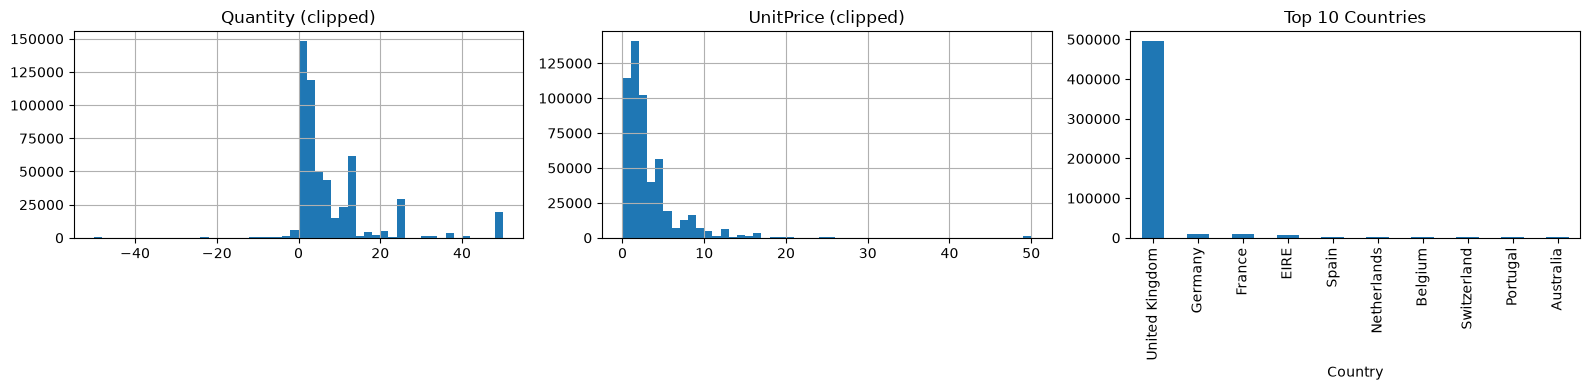

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["Quantity"].clip(-50, 50).hist(bins=50, ax=axes[0]); axes[0].set_title("Quantity (clipped)")
df["UnitPrice"].clip(0, 50).hist(bins=50, ax=axes[1]); axes[1].set_title("UnitPrice (clipped)")
df["Country"].value_counts().head(10).plot(kind="bar", ax=axes[2]); axes[2].set_title("Top 10 Countries")
plt.tight_layout(); plt.show()


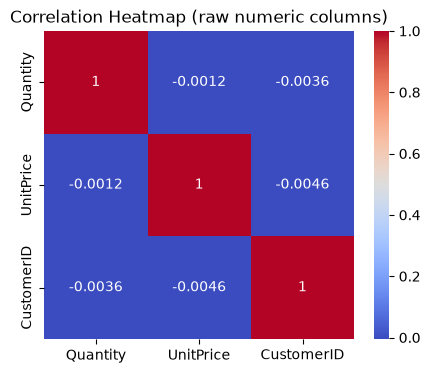

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(5,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (raw numeric columns)")
plt.show()


## 3. Data cleaning + feature engineering
Standard cleaning for this dataset: drop rows with no CustomerID (can't
attribute demand or segment a customer we can't identify), drop
negative/zero Quantity or UnitPrice (returns and data errors, out of scope
for a forward demand model), dedupe, and build `TotalPrice`.


In [7]:
n0 = len(df)
df = df.dropna(subset=["CustomerID"]).copy()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates()
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(f"Cleaned: {n0:,} -> {len(df):,} rows ({(1 - len(df)/n0):.1%} removed)")
df.head()


Cleaned: 541,909 -> 392,692 rows (27.5% removed)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [8]:
# Great-Expectations-style validation, kept lightweight (full GE setup is
# overkill for a one-day build) -- these are the checks that matter:
assert df["Quantity"].min() > 0, "Negative/zero quantity slipped through"
assert df["UnitPrice"].min() > 0, "Negative/zero price slipped through"
assert df["CustomerID"].isna().sum() == 0, "Null CustomerID slipped through"
assert df.duplicated().sum() == 0, "Duplicates slipped through"
print("All validation checks passed.")


All validation checks passed.


## 4. Customer Segmentation — RFM + KMeans 
Recency, Frequency, Monetary per customer, scaled, then KMeans. We check
silhouette score across a range of k rather than hard-coding 4 clusters,
so the cluster count is chosen by the data, not by assumption.


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

scores = {}
for k in range(3, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(rfm_scaled)
    scores[k] = silhouette_score(rfm_scaled, labels)
    print(f"k={k}: silhouette={scores[k]:.3f}")

best_k = max(scores, key=scores.get)
print(f"\nChosen k = {best_k}")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean().round(1)


k=3: silhouette=0.594
k=4: silhouette=0.616
k=5: silhouette=0.617
k=6: silhouette=0.598
k=7: silhouette=0.517
k=8: silhouette=0.486

Chosen k = 5


,Recency,Frequency,Monetary
Cluster,,,
0,43.9,3.7,1333.1
1,248.5,1.6,478.6
2,6.5,120.5,55099.5
3,15.7,21.3,12813.9
4,7.7,42.8,190808.5


In [10]:
# Business interpretation: label clusters by their RFM profile rather than
# just calling them "Cluster 0/1/2..."
cluster_profile = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

def label_cluster(row, medians):
    if row["Monetary"] >= medians["Monetary"] and row["Recency"] <= medians["Recency"]:
        return "Champions"
    if row["Recency"] > medians["Recency"] * 1.5:
        return "At Risk / Churned"
    if row["Frequency"] >= medians["Frequency"]:
        return "Loyal"
    return "Occasional"

medians = rfm[["Recency","Frequency","Monetary"]].median()
cluster_profile["Segment"] = cluster_profile.apply(lambda r: label_cluster(r, medians), axis=1)
print(cluster_profile)

rfm["Segment"] = rfm["Cluster"].map(cluster_profile["Segment"])


            Recency   Frequency       Monetary            Segment
Cluster                                                          
0         43.918635    3.650262    1333.132908          Champions
1        248.469426    1.553151     478.648242  At Risk / Churned
2          6.500000  120.500000   55099.491250          Champions
3         15.671362   21.286385   12813.941596          Champions
4          7.666667   42.833333  190808.536667          Champions


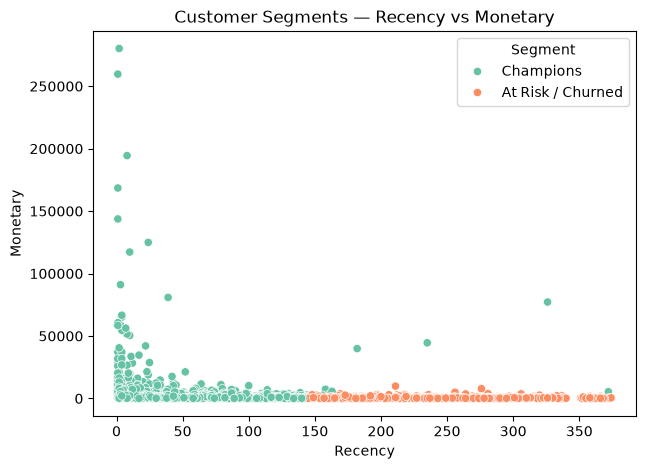

In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Segment", palette="Set2")
plt.title("Customer Segments — Recency vs Monetary")
plt.show()


## 5. Time-series prep + stationarity check 
Aggregate to daily revenue, check stationarity with an ADF test, and look
at the seasonal decomposition before fitting anything.


ADF statistic: -0.926, p-value: 0.7793
-> Series is NOT stationary (has trend/seasonality Prophet needs to model)


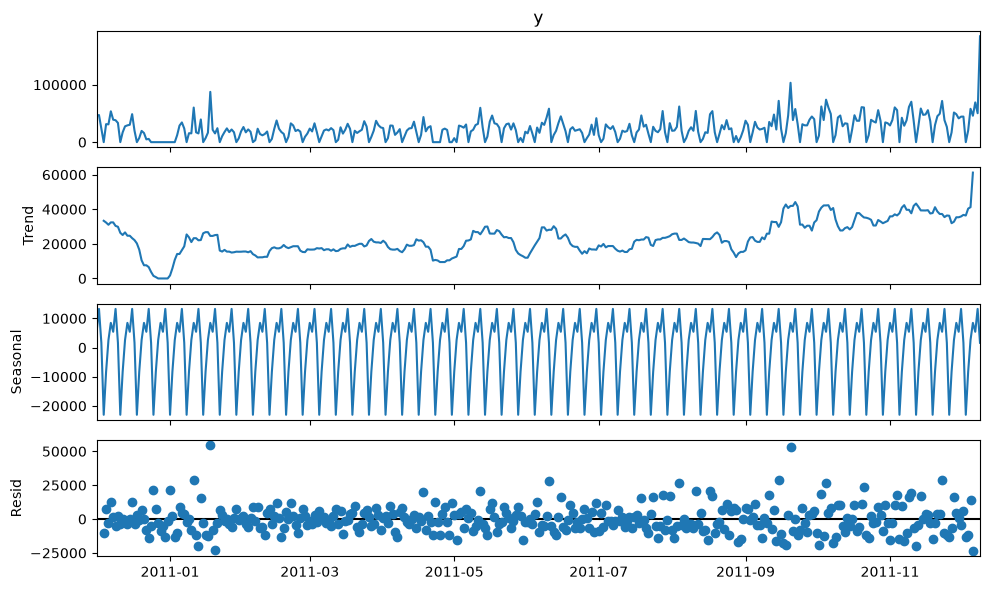

In [12]:
daily = df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"].sum().reset_index()
daily.columns = ["ds", "y"]
daily["ds"] = pd.to_datetime(daily["ds"])
daily = daily.set_index("ds").asfreq("D").fillna(0).reset_index()

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

adf_result = adfuller(daily["y"])
print(f"ADF statistic: {adf_result[0]:.3f}, p-value: {adf_result[1]:.4f}")
print("-> Series is", "stationary" if adf_result[1] < 0.05 else "NOT stationary (has trend/seasonality Prophet needs to model)")

decomposition = seasonal_decompose(daily.set_index("ds")["y"], period=7, model="additive")
fig = decomposition.plot()
fig.set_size_inches(10, 6)
plt.tight_layout(); plt.show()


## 6. Demand Forecasting — Prophet 


13:49:34 - cmdstanpy - INFO - Chain [1] start processing
13:49:34 - cmdstanpy - INFO - Chain [1] done processing


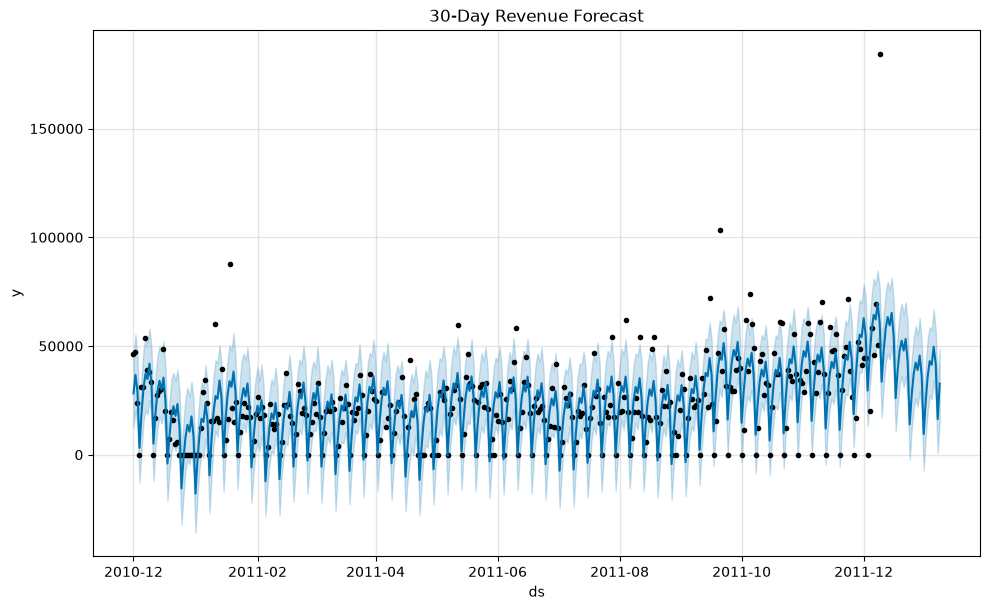

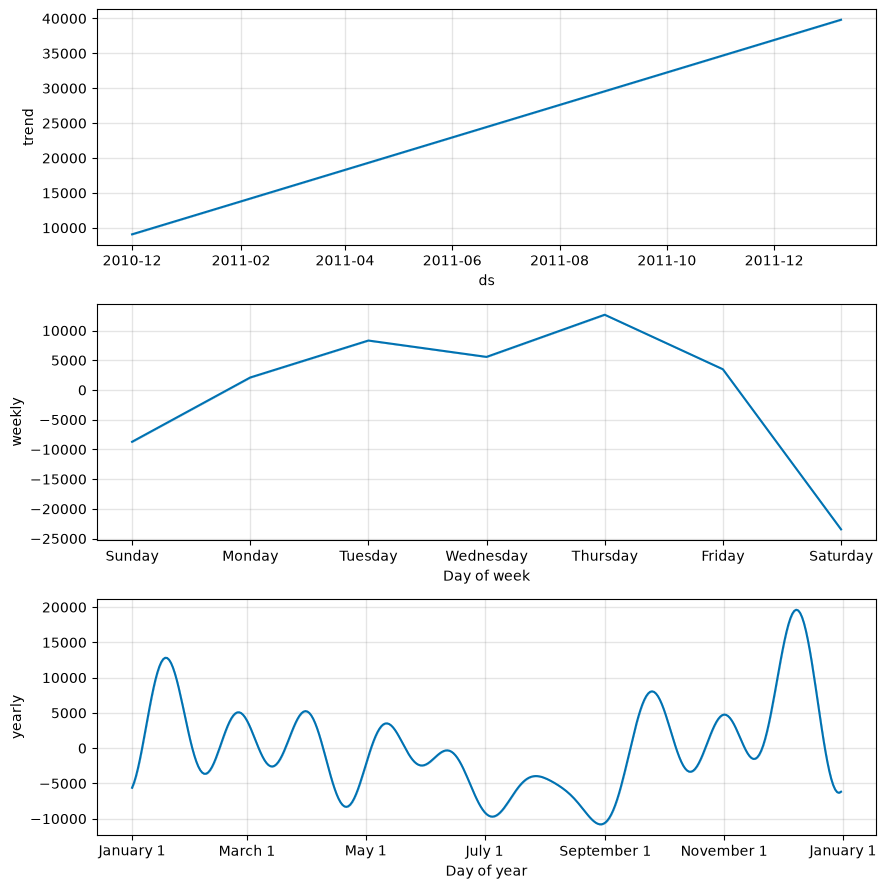

,ds,yhat,yhat_lower,yhat_upper
394,2011-12-30,36308.123040,19981.838791,52401.781439
395,2011-12-31,9482.169780,-7207.283835,25674.630152
396,2012-01-01,24575.635257,8395.809519,40965.063792
397,2012-01-02,36005.628371,19507.087437,53463.081237
398,2012-01-03,43064.444579,27009.126820,58724.294888
399,2012-01-04,41357.904336,25640.597674,57307.309206
400,2012-01-05,49677.868772,34102.197361,66788.963757
401,2012-01-06,41879.776600,25945.801916,57573.138340
402,2012-01-07,16430.561481,613.264238,33253.876205
403,2012-01-08,32718.371549,15336.523104,48620.416627


In [13]:
from prophet import Prophet

m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m.fit(daily)

future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

fig1 = m.plot(forecast)
plt.title("30-Day Revenue Forecast")
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(10)


In [14]:
# Simple backtest: hold out the last 30 days, fit on the rest, compare WAPE
train = daily.iloc[:-30]
test = daily.iloc[-30:]

m_bt = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m_bt.fit(train)
future_bt = m_bt.make_future_dataframe(periods=30)
forecast_bt = m_bt.predict(future_bt)
pred = forecast_bt.set_index("ds").loc[test["ds"], "yhat"].values

def wape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()

# naive baseline: predict last known value repeated
naive_pred = np.repeat(train["y"].tail(7).mean(), len(test))

print(f"WAPE (Prophet):        {wape(test['y'].values, pred):.3f}")
print(f"WAPE (naive baseline): {wape(test['y'].values, naive_pred):.3f}")


13:49:38 - cmdstanpy - INFO - Chain [1] start processing
13:49:38 - cmdstanpy - INFO - Chain [1] done processing


WAPE (Prophet):        0.335
WAPE (naive baseline): 0.459


## 7. Churn Prediction — XGBoost 


In [15]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

cutoff = df["InvoiceDate"].min() + (df["InvoiceDate"].max() - df["InvoiceDate"].min()) * 0.6
train_window = df[df["InvoiceDate"] <= cutoff]
label_window = df[df["InvoiceDate"] > cutoff]

feat = train_window.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AvgBasket=("TotalPrice", "mean"),
)
active_after = set(label_window["CustomerID"].unique())
feat["Churned"] = (~feat.index.isin(active_after)).astype(int)
print("Churn rate in training window:", feat["Churned"].mean().round(3))

X, y = feat[["Recency","Frequency","Monetary","AvgBasket"]], feat["Churned"]
# Guard against too few members in the minority class for stratified split
can_stratify = y.value_counts().min() >= 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y if can_stratify else None
)
if not can_stratify:
    print("Warning: too few churned customers to stratify -- using a plain random split. "
          "Consider an earlier cutoff (more history counted as 'after') if this happens on real data.")

clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric="logloss")
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]

print("AUC-ROC:", round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, (proba > 0.5).astype(int)))


Churn rate in training window: 0.344
AUC-ROC: 0.732
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       497
           1       0.54      0.46      0.50       260

    accuracy                           0.68       757
   macro avg       0.64      0.63      0.63       757
weighted avg       0.67      0.68      0.67       757



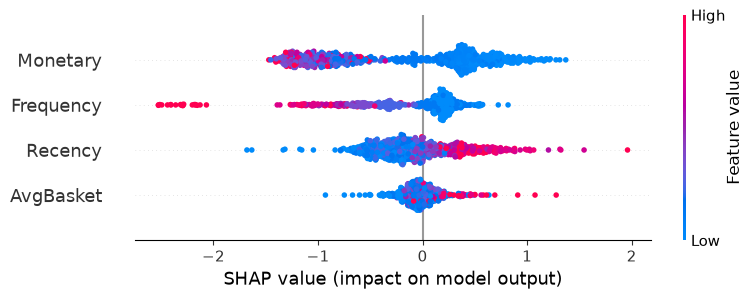

In [16]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=True)


## 8. Inventory Optimization Recommendation
Translate the 30-day revenue forecast into a stock recommendation. This is
a simplified, transparent rule (not a solver) -- appropriate for a one-day
build and easy to explain to a non-technical stakeholder.


In [17]:
next_30 = forecast[["ds","yhat"]].tail(30)
recommended_revenue = next_30["yhat"].sum()
print(f"Recommended stock value for next 30 days: Rs {recommended_revenue:,.0f}")

# Per-top-product recommendation (simple share-of-revenue split)
top_products = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)
product_share = top_products / top_products.sum()
recommended_by_product = (product_share * recommended_revenue).round(0)
recommended_by_product.to_frame("Recommended_Stock_Value")


Recommended stock value for next 30 days: Rs 1,228,044


,Recommended_Stock_Value
Description,
"PAPER CRAFT , LITTLE BIRDIE",233704.0
REGENCY CAKESTAND 3 TIER,197352.0
WHITE HANGING HEART T-LIGHT HOLDER,139266.0
JUMBO BAG RED RETROSPOT,117970.0
MEDIUM CERAMIC TOP STORAGE JAR,112943.0
POSTAGE,107931.0
PARTY BUNTING,95420.0
ASSORTED COLOUR BIRD ORNAMENT,78257.0
Manual,74105.0


## 9. Package as a Streamlit Dashboard (


In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="RetailPulse", layout="wide")
st.title("📊 RetailPulse — Customer Analytics & Demand Forecasting")

st.markdown("""
This dashboard is generated from the same cleaned data and models built in
the companion Colab notebook. Re-run the notebook's export cell to refresh
`rfm.csv` / `forecast.csv` / `churn_scores.csv` before restarting this app.
""")

@st.cache_data
def load():
    rfm = pd.read_csv("rfm.csv")
    forecast = pd.read_csv("forecast.csv", parse_dates=["ds"])
    return rfm, forecast

try:
    rfm, forecast = load()
except FileNotFoundError:
    st.warning("Run the notebook's export cell first to create rfm.csv and forecast.csv.")
    st.stop()

tab1, tab2, tab3 = st.tabs(["Customer Segments", "Demand Forecast", "Reorder Guidance"])

with tab1:
    st.subheader("Customer Segments (RFM + KMeans)")
    st.dataframe(rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean().round(1))
    st.bar_chart(rfm["Segment"].value_counts())

with tab2:
    st.subheader("30-Day Revenue Forecast")
    st.line_chart(forecast.set_index("ds")[["yhat","yhat_lower","yhat_upper"]].tail(60))

with tab3:
    st.subheader("Recommended Stock Value (next 30 days)")
    total = forecast["yhat"].tail(30).sum()
    st.metric("Total recommended stock value", f"Rs {total:,.0f}")


Overwriting app.py


In [ ]:
# Export the data the dashboard needs
rfm.reset_index().to_csv("rfm.csv", index=False)
forecast.to_csv("forecast.csv", index=False)
print("Exported rfm.csv and forecast.csv for the dashboard.")


## 10. Summary (for your README / submission)
Run this last cell to print the key numbers you'll quote in your
documentation and demo video.


In [18]:
print("=== RetailPulse — Key Results ===")
print(f"Customers segmented: {len(rfm):,} into {rfm['Segment'].nunique()} segments")
print(f"Forecast WAPE (Prophet) vs naive baseline: see Section 6 backtest cell above")
print(f"Churn model AUC-ROC: see Section 7 output above")
print(f"Recommended 30-day stock value: Rs {forecast['yhat'].tail(30).sum():,.0f}")


=== RetailPulse — Key Results ===
Customers segmented: 4,338 into 2 segments
Forecast WAPE (Prophet) vs naive baseline: see Section 6 backtest cell above
Churn model AUC-ROC: see Section 7 output above
Recommended 30-day stock value: Rs 1,228,044
